Import Libraries

In [29]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re
from collections import Counter

import nltk

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\harsh\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\harsh\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\harsh\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Load Dataset

In [30]:
fake = pd.read_csv("Fake.csv")
true = pd.read_csv("True.csv")

In [31]:
fake["label"] = 0
true["label"] = 1

Combine Dataset

In [32]:
data = pd.concat([fake, true], ignore_index=True)

data = data.sample(frac=1, random_state=42)

data.reset_index(drop=True, inplace=True)

Dataset Shape

In [33]:
print("Dataset Shape")

print(data.shape)

Dataset Shape
(44898, 5)


Column Names

In [34]:
print(data.columns)

Index(['title', 'text', 'subject', 'date', 'label'], dtype='str')


Data Types

In [35]:
print(data.dtypes)

title        str
text         str
subject      str
date         str
label      int64
dtype: object


Missing Values

In [36]:
print(data.isnull().sum())

title      0
text       0
subject    0
date       0
label      0
dtype: int64


Class Distribution

In [37]:
print(data["label"].value_counts())

label
0    23481
1    21417
Name: count, dtype: int64


Class Distribution Graph

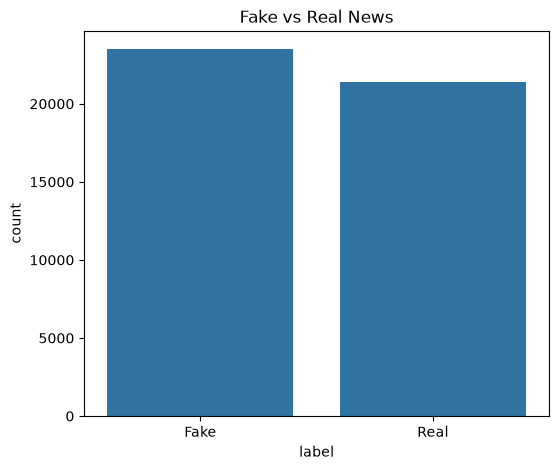

In [38]:
plt.figure(figsize=(6,5))

sns.countplot(x="label", data=data)

plt.xticks([0,1],["Fake","Real"])

plt.title("Fake vs Real News")

plt.show()

Stop Words & Lemmatizer

In [39]:
stop_words = set(stopwords.words("english"))

lemmatizer = WordNetLemmatizer()

Cleaning Function

In [40]:
def clean_text(text):
    
    text = str(text).lower()

    text = re.sub(r"http\S+","",text)

    text = re.sub(r"<.*?>","",text)

    text = re.sub(r"[^a-zA-Z\s]","",text)

    text = re.sub(r"\d+","",text)

    words = text.split()

    words = [word for word in words if word not in stop_words]

    words = [lemmatizer.lemmatize(word) for word in words]

    return " ".join(words)

Apply Cleaning

In [41]:
data["clean_text"] = data["text"].apply(clean_text)

TF-IDF

In [42]:
tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(data["clean_text"])

y = data["label"]

Train Test Split

In [43]:
X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.2,

    random_state=42

)

Logistic Regression

In [44]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

Prediction

In [45]:
train_pred = model.predict(X_train)

test_pred = model.predict(X_test)

Training & Testing Accuracy

In [46]:
train_accuracy = accuracy_score(y_train, train_pred)

test_accuracy = accuracy_score(y_test, test_pred)

print("Training Accuracy :", train_accuracy)

print("Testing Accuracy :", test_accuracy)

Training Accuracy : 0.9913970711064091
Testing Accuracy : 0.9841870824053452


Evaluation Metrics

In [47]:
print("Accuracy :", accuracy_score(y_test, test_pred))

print("Precision :", precision_score(y_test, test_pred))

print("Recall :", recall_score(y_test, test_pred))

print("F1 Score :", f1_score(y_test, test_pred))

Accuracy : 0.9841870824053452
Precision : 0.9786641929499073
Recall : 0.9882903981264637
F1 Score : 0.9834537403868562


Classification Report

In [48]:
print(classification_report(y_test, test_pred))

              precision    recall  f1-score   support

           0       0.99      0.98      0.98      4710
           1       0.98      0.99      0.98      4270

    accuracy                           0.98      8980
   macro avg       0.98      0.98      0.98      8980
weighted avg       0.98      0.98      0.98      8980



Confusion Matrix

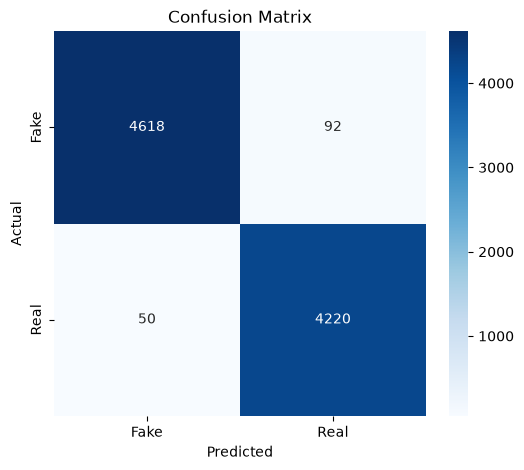

In [49]:
cm = confusion_matrix(y_test, test_pred)

plt.figure(figsize=(6,5))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues",

    xticklabels=["Fake","Real"],

    yticklabels=["Fake","Real"]

)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

Top 10 Frequent Words

In [50]:
all_words = " ".join(data["clean_text"])

word_list = all_words.split()

counter = Counter(word_list)

top10 = counter.most_common(10)

words = [i[0] for i in top10]

counts = [i[1] for i in top10]

Bar Graph

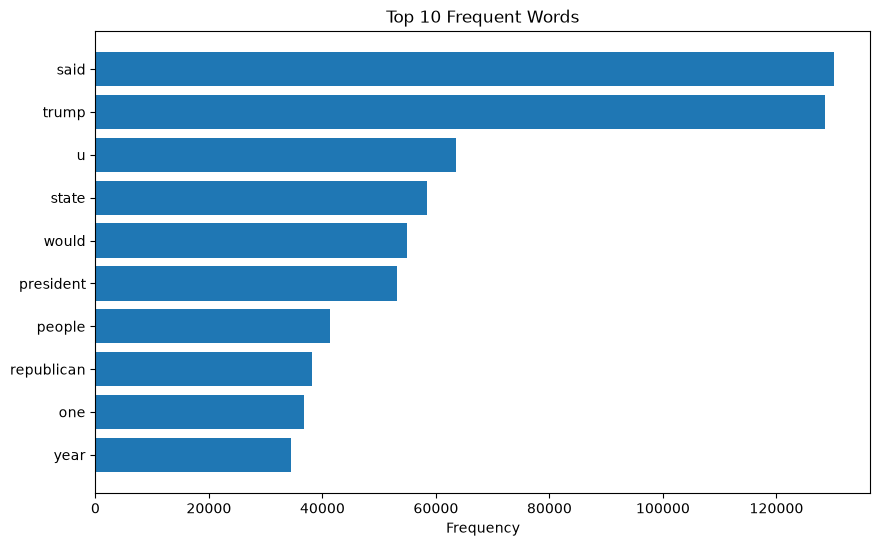

In [51]:
plt.figure(figsize=(10,6))

plt.barh(words, counts)

plt.xlabel("Frequency")

plt.title("Top 10 Frequent Words")

plt.gca().invert_yaxis()

plt.show()

Custom Prediction Function

In [52]:
def predict_news(news):
    
    cleaned = clean_text(news)

    vector = tfidf.transform([cleaned])

    prediction = model.predict(vector)

    if prediction[0] == 0:

        print("Fake News")

    else:

        print("Real News")

User Input

In [53]:
news = input("The Reserve Bank of India announced a new monetary policy to control inflation.")

predict_news(news)

Fake News
